# Diagnóstico de calidad, adecuación, cobertura y limitaciones de los datos

**Proyecto de Aprendizaje Automático (PAA) — UTEC / LIDIA 2026 · Predicción de siniestros viales**

Este notebook produce la evidencia que respalda el diagnóstico de datos exigido por el
Entregable 2 de la guía PAA (sección 5.2) y la sección *Metodología — datos* del informe
(guía 6.1: calidad, cobertura, representatividad, sesgos y restricciones de uso).

**Qué responde**

| Eje | Pregunta |
|---|---|
| Calidad | ¿Los registros son completos, consistentes y precisos para lo que se les va a pedir? |
| Cobertura | ¿Qué territorio, qué período y qué fracción de la unidad de análisis observan realmente? |
| Adecuación | ¿La variable objetivo y las variables disponibles sostienen el problema planteado? |
| Limitaciones | ¿Qué no puede afirmarse con estos datos y qué riesgos introduce cada decisión? |

**Alcance.** Se diagnostica la fuente cruda (`data/raw/uru_siniestros_unificado.csv`, heredada
del PID) y la unidad de análisis día × zona que define
[`analisis_inicial.ipynb`](analisis_inicial.ipynb). Todo se **recalcula desde el crudo**, de
modo que el diagnóstico no depende de que los derivados estén construidos; por separado
(sección 2.6) se comprueba que los artefactos de `data/processed/` sean coherentes con esa
definición. El notebook es de **solo lectura** sobre `data/`: no reescribe el panel ni las
*features*.

**Qué deja como artefacto.** Todas las tablas y figuras se escriben en
`experiments/diagnostico_datos/`, de modo que cada cifra citada en el informe pueda rastrearse
hasta un archivo del repositorio (regla de trazabilidad, guía 4.4 y 6.3).

**Ejecución.** Con el entorno del `README.md` activado, ejecutar el notebook de arriba a abajo.
No requiere descargas ni credenciales.

## 0. Configuración y trazabilidad de la fuente

In [1]:
import hashlib
import importlib.metadata as md
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import holidays
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import display

# Raíz del repo: funciona sin importar desde dónde se abra el notebook
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw").is_dir())
RUTA_CSV = RAIZ / "data" / "raw" / "uru_siniestros_unificado.csv"
DIR_PROC = RAIZ / "data" / "processed"

# Artefactos del diagnóstico (citables desde el informe)
DIR_SALIDA = RAIZ / "experiments" / "diagnostico_datos"
DIR_TABLAS = DIR_SALIDA / "tablas"
DIR_FIGURAS = DIR_SALIDA / "figuras"
for d in (DIR_TABLAS, DIR_FIGURAS):
    d.mkdir(parents=True, exist_ok=True)

# Constantes del diseño, iguales a las de analisis_inicial.ipynb (si cambian allí, cambian aquí)
TAM_CELDA = 500          # metros de lado de la celda espacial
ANIO_INICIO = 2019       # 2018 es período de calentamiento de las medias móviles
SEMILLA = 42

# División cronológica del período de modelado (ver 3.2). Se reserva el 20 % final como test
# y el 80 % restante se reparte en entrenamiento (70 %) y validación (10 %) del total.
PROP_TRAIN, PROP_VALID, PROP_TEST = 0.70, 0.10, 0.20

# Superficie continental de Uruguay, usada sólo como referencia de cobertura territorial (INE)
SUPERFICIE_UY_KM2 = 176_215

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})
rng = np.random.default_rng(SEMILLA)


def guardar_tabla(tabla: pd.DataFrame, nombre: str, indice: bool = False) -> None:
    """Escribe la tabla como CSV en experiments/ y la muestra en el notebook."""
    destino = DIR_TABLAS / f"{nombre}.csv"
    tabla.to_csv(destino, index=indice, encoding="utf-8")
    print(f"[tabla]  {destino.relative_to(RAIZ)}")
    display(tabla)


def guardar_figura(fig, nombre: str) -> None:
    destino = DIR_FIGURAS / f"{nombre}.png"
    fig.savefig(destino)
    print(f"[figura] {destino.relative_to(RAIZ)}")

In [2]:
# Procedencia: identifica sin ambigüedad el archivo diagnosticado y el entorno que lo leyó
sha = hashlib.sha256(RUTA_CSV.read_bytes()).hexdigest()
paquetes = ["pandas", "numpy", "pyarrow", "matplotlib", "holidays", "scikit-learn"]

procedencia = pd.DataFrame(
    [
        ("archivo", str(RUTA_CSV.relative_to(RAIZ))),
        ("tamaño_MB", f"{RUTA_CSV.stat().st_size / 1e6:.1f}"),
        ("sha256", sha),
        ("modificado", datetime.fromtimestamp(RUTA_CSV.stat().st_mtime).strftime("%Y-%m-%d %H:%M")),
        ("ejecutado", datetime.now(timezone.utc).astimezone().strftime("%Y-%m-%d %H:%M")),
        ("python", f"{sys.version.split()[0]} · {platform.system()} {platform.release()}"),
    ]
    + [(p, md.version(p)) for p in paquetes],
    columns=["clave", "valor"],
)
guardar_tabla(procedencia, "00_procedencia")

[tabla]  experiments\diagnostico_datos\tablas\00_procedencia.csv


,clave,valor
0,archivo,data\raw\uru_siniestros_unificado.csv
1,tamaño_MB,26.2
2,sha256,48a8a7e8f06ed8aa1d138b9921995d81a2c86cb3858354...
3,modificado,2026-08-24 11:21
4,ejecutado,2026-08-31 09:15
5,python,3.13.2 · Windows 10
6,pandas,3.0.5
7,numpy,2.5.2
8,pyarrow,25.0.1
9,matplotlib,3.11.1


El *hash* identifica la versión exacta del archivo diagnosticado. Si la fuente se actualiza,
el `sha256` cambia y el diagnóstico debe volver a ejecutarse: es lo que permite afirmar en el
informe que las cifras corresponden a un archivo concreto y no a «los datos» en abstracto.

## 1. Fuente, unidad de análisis y disponibilidad de las variables

In [3]:
# skipinitialspace: el CSV trae un espacio después de cada coma; los encabezados también
df = pd.read_csv(RUTA_CSV, skipinitialspace=True, encoding="utf-8")
df.columns = df.columns.str.strip()
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%m/%d/%Y")
df["anio"] = df["Fecha"].dt.year

N = len(df)
COLS_CRUDAS = [c for c in df.columns if c != "anio"]
print(f"{N:,} registros × {len(COLS_CRUDAS)} columnas")
print(f"período: {df['Fecha'].min():%Y-%m-%d} → {df['Fecha'].max():%Y-%m-%d}")

esquema = pd.DataFrame({
    "tipo": df[COLS_CRUDAS].dtypes.astype(str),
    "no_nulos": df[COLS_CRUDAS].notna().sum(),
    "distintos": df[COLS_CRUDAS].nunique(),
    "ejemplo": df[COLS_CRUDAS].iloc[0].astype(str),
}).reset_index(names="columna")
guardar_tabla(esquema, "01_esquema_crudo")

224,694 registros × 11 columnas
período: 2018-01-01 → 2025-12-31
[tabla]  experiments\diagnostico_datos\tablas\01_esquema_crudo.csv


,columna,tipo,no_nulos,distintos,ejemplo
0,Fecha,datetime64[us],224694,2922,2018-07-24 00:00:00
1,Calle,str,224693,23966,AVENIDA DIECIOCHO DE JULIO
2,Tipo de Siniestro,str,224694,9,ATROPELLO DE PEATÓN
3,Gravedad,str,224694,4,LEVE
4,Dia Semana,str,224694,7,MARTES
5,Hora,int64,224694,24,16
6,Departamento,str,224694,19,MONTEVIDEO
7,Localidad,str,224694,455,MONTEVIDEO
8,fixed,int64,224694,1,1
9,X,int64,224694,35532,575370


In [4]:
# Composición de las columnas que describen el siniestro. No se usan como predictoras (1.2),
# pero caracterizan qué tipo de evento llega al registro y sirven para segmentar el análisis
# de errores más adelante.
composicion = pd.concat([
    pd.DataFrame({
        "columna": col,
        "valor": df[col].value_counts().index,
        "registros": df[col].value_counts().to_numpy(),
    })
    for col in ("Gravedad", "Tipo de Siniestro")
], ignore_index=True)
composicion["pct"] = (100 * composicion["registros"] / N).round(2)
guardar_tabla(composicion, "01b_composicion_descriptiva")

[tabla]  experiments\diagnostico_datos\tablas\01b_composicion_descriptiva.csv


,columna,valor,registros,pct
0,Gravedad,LEVE,134706,59.95
1,Gravedad,SIN LESIONADOS,63173,28.12
2,Gravedad,GRAVE,23567,10.49
3,Gravedad,FATAL,3248,1.45
4,Tipo de Siniestro,COLISIÓN ENTRE VEHÍCULOS,146010,64.98
5,Tipo de Siniestro,CAÍDA,25942,11.55
6,Tipo de Siniestro,DESPISTE,25187,11.21
7,Tipo de Siniestro,ATROPELLO DE PEATÓN,12751,5.67
8,Tipo de Siniestro,ATROPELLO DE ANIMALES,7987,3.55
9,Tipo de Siniestro,COLISIÓN CON OBSTÁCULO EN CALZADA,6792,3.02


El registro no se limita a los siniestros graves: **el 28,1 % son «SIN LESIONADOS»** y casi el
60 % «LEVE», frente a un 10,5 % de graves y un 1,4 % de fatales. Una fuente que sólo recogiera
siniestros con víctimas no tendría esa composición, de modo que la cobertura parece amplia. No
es una prueba de ausencia de subregistro —eso exigiría una fuente externa de contraste—, pero sí
el único indicio interno disponible al respecto (ver sección 5).

Dos categorías de `Tipo de Siniestro` tienen un solo registro cada una (`VUELCO` y
`COLISIÓN CON OBSTACULO EN CALZADA`, esta última una variante sin tilde de una categoría ya
existente con 6.792 registros). Son ruido de codificación, sin efecto sobre el PAA porque la
columna no se usa; se anota por si se la emplea para segmentar errores.

### 1.1 Unidad de análisis

El registro crudo es un **siniestro**. La unidad de análisis del PAA, en cambio, es el par
**(día, zona)** —una celda de 500 × 500 m sobre las coordenadas UTM 21S—, y la variable
objetivo es el **conteo de siniestros** de esa zona ese día. El cambio de unidad no es
cosmético: convierte 224.694 eventos en un panel de decenas de millones de celdas mayormente
vacías, y buena parte de este diagnóstico existe para medir las consecuencias de esa
transformación (secciones 3.4 y 4).

### 1.2 Qué variables están disponibles en el momento de la predicción

La restricción de la guía (6.1: *evitar incorporar información que no estaría disponible en el
momento real de la predicción*) descarta la mayoría de las columnas. `Gravedad`, `Tipo de
Siniestro` y `Hora` describen un siniestro **que ya ocurrió**: usarlas como predictoras del
día siguiente equivale a conocer el resultado que se quiere anticipar.

In [5]:
# Rol de cada columna en el problema de pronóstico. La clasificación es una decisión del
# equipo, no un cálculo: se versiona como tabla para poder citarla y discutirla.
roles = pd.DataFrame(
    [
        ("Fecha", "define el período de la unidad de análisis", "sí", "eje temporal del panel"),
        ("X, Y", "definen la zona (celda de 500 m)", "sí", "eje espacial del panel"),
        ("Departamento", "atributo territorial de la zona", "sí", "descriptivo / agrupación"),
        ("Localidad", "atributo territorial de la zona", "parcial", "faltante encubierto (ver 2.1)"),
        ("Calle", "texto libre del lugar", "parcial", "alta cardinalidad; no se usa"),
        ("Dia Semana", "derivable de Fecha", "sí", "redundante: se recalcula"),
        ("Hora", "hora del siniestro ocurrido", "no", "posterior al evento"),
        ("Tipo de Siniestro", "clasificación del siniestro ocurrido", "no", "posterior al evento"),
        ("Gravedad", "consecuencia del siniestro ocurrido", "no", "posterior al evento"),
        ("fixed", "marca del proceso ETL del PID", "no", "constante: sin información"),
    ],
    columns=["columna", "qué es", "disponible antes del evento", "uso en el PAA"],
)
guardar_tabla(roles, "02_disponibilidad_variables")

[tabla]  experiments\diagnostico_datos\tablas\02_disponibilidad_variables.csv


,columna,qué es,disponible antes del evento,uso en el PAA
0,Fecha,define el período de la unidad de análisis,sí,eje temporal del panel
1,"X, Y",definen la zona (celda de 500 m),sí,eje espacial del panel
2,Departamento,atributo territorial de la zona,sí,descriptivo / agrupación
3,Localidad,atributo territorial de la zona,parcial,faltante encubierto (ver 2.1)
4,Calle,texto libre del lugar,parcial,alta cardinalidad; no se usa
5,Dia Semana,derivable de Fecha,sí,redundante: se recalcula
6,Hora,hora del siniestro ocurrido,no,posterior al evento
7,Tipo de Siniestro,clasificación del siniestro ocurrido,no,posterior al evento
8,Gravedad,consecuencia del siniestro ocurrido,no,posterior al evento
9,fixed,marca del proceso ETL del PID,no,constante: sin información


De once columnas, sólo **`Fecha`, `X` e `Y`** construyen la unidad de análisis y la variable
objetivo; `Departamento` sirve para agrupar y describir. Las tres columnas más ricas del
archivo (`Gravedad`, `Tipo de Siniestro`, `Hora`) son **posteriores al evento** y quedan fuera
del conjunto de predictoras. La consecuencia es directa y conviene declararla en el informe:
*el poder predictivo no puede venir de los atributos del siniestro, sino del historial de la
zona y del calendario* —y, cuando se integre, del clima—. Esas columnas siguen siendo útiles
para caracterizar el fenómeno y para segmentar el análisis de errores, no para alimentar el
modelo.

## 2. Calidad

### 2.1 Completitud: nulos explícitos y faltantes encubiertos

Los faltantes de este archivo casi no aparecen como `NaN`: vienen codificados como texto
(`SIN DATOS`, `NO SE INGRESO`). Contar sólo nulos explícitos daría una completitud aparente
del 100 % y sería un error de diagnóstico.

In [6]:
CENTINELAS = ("SIN DATOS", "NO SE INGRESO", "NO SE INGRESÓ", "SIN DATO")

filas = []
for col in COLS_CRUDAS:
    serie = df[col]
    nulos = int(serie.isna().sum())
    if not pd.api.types.is_numeric_dtype(serie):
        texto = serie.astype("string").fillna("").str.upper().str.strip()
        centinela = int(texto.isin(CENTINELAS).sum())
    else:
        centinela = 0
    filas.append((col, nulos, centinela, nulos + centinela, 100 * (nulos + centinela) / N))

completitud = pd.DataFrame(
    filas, columns=["columna", "nulos", "centinela_texto", "faltante_total", "pct_faltante"]
).round({"pct_faltante": 2}).sort_values("faltante_total", ascending=False)
guardar_tabla(completitud, "03_completitud")

[tabla]  experiments\diagnostico_datos\tablas\03_completitud.csv


,columna,nulos,centinela_texto,faltante_total,pct_faltante
7,Localidad,0,40238,40238,17.91
1,Calle,1,27792,27793,12.37
2,Tipo de Siniestro,0,23,23,0.01
0,Fecha,0,0,0,0.00
3,Gravedad,0,0,0,0.00
5,Hora,0,0,0,0.00
4,Dia Semana,0,0,0,0.00
6,Departamento,0,0,0,0.00
8,fixed,0,0,0,0.00
9,X,0,0,0,0.00


`Localidad` es la columna más afectada (**40.238 registros, 17,91 %**) y `Calle` la sigue
(**27.793, 12,37 %**: un único nulo explícito y 27.792 centinelas repartidos entre `SIN DATOS`
y `NO SE INGRESO`). Ninguna de las dos se
usa como predictora, de modo que el faltante **no compromete al modelo**; sí impide usar la
localidad como unidad territorial alternativa a la grilla, que era una de las opciones
consideradas. Las columnas que sostienen la unidad de análisis —`Fecha`, `X`, `Y`— están
completas.

### 2.2 Duplicados

El archivo no tiene identificador de siniestro, así que un duplicado exacto es
**indistinguible** de dos siniestros reales ocurridos el mismo día, a la misma hora, en el
mismo punto y del mismo tipo —algo posible en una intersección concurrida—. Se cuantifica el
fenómeno y se deja explícita la ambigüedad en lugar de resolverla por defecto.

In [7]:
dup_exactos = df[COLS_CRUDAS].duplicated()
por_anio = df.loc[dup_exactos, "anio"].value_counts().sort_index()

# Coincidencias en la clave "física" del evento, aunque difieran los atributos descriptivos
grupos = df.groupby(["Fecha", "Hora", "X", "Y"]).size()

resumen_dup = pd.DataFrame(
    [
        ("duplicados exactos (todas las columnas)", int(dup_exactos.sum()), 100 * dup_exactos.sum() / N),
        ("grupos con >1 registro en (fecha, hora, X, Y)", int((grupos > 1).sum()), float("nan")),
        ("registros dentro de esos grupos", int(grupos[grupos > 1].sum()), 100 * grupos[grupos > 1].sum() / N),
    ],
    columns=["criterio", "cantidad", "pct_registros"],
).round({"pct_registros": 3})
guardar_tabla(resumen_dup, "04_duplicados")
print("\nduplicados exactos por año:")
print(por_anio.to_string())

[tabla]  experiments\diagnostico_datos\tablas\04_duplicados.csv


,criterio,cantidad,pct_registros
0,duplicados exactos (todas las columnas),347,0.154
1,"grupos con >1 registro en (fecha, hora, X, Y)",524,NaN
2,registros dentro de esos grupos,1076,0.479



duplicados exactos por año:
anio
2018    58
2019    45
2020    24
2021    47
2022    45
2023    47
2024    51
2025    30


**347 duplicados exactos (0,15 %)**, repartidos de forma pareja entre 2018 y 2025 (entre 24 y
58 por año). La regularidad interanual descarta un error puntual de carga —un archivo cargado
dos veces produciría una concentración en un año o un mes— y es compatible con siniestros
múltiples registrados por separado. Se **conservan**: eliminarlos supondría que dos eventos no
pueden coincidir en día, hora y punto, supuesto que el archivo no permite verificar. El impacto
sobre la variable objetivo está acotado al 0,15 % del total, muy por debajo de la variabilidad
del propio conteo.

### 2.3 Consistencia interna

Cuatro comprobaciones que un archivo integrado desde varias fuentes puede fallar: coherencia
entre campos redundantes, rangos válidos, columnas sin variabilidad y coherencia entre la
etiqueta territorial y la geometría.

In [8]:
DIAS_ES = {0: "LUNES", 1: "MARTES", 2: "MIÉRCOLES", 3: "JUEVES",
           4: "VIERNES", 5: "SÁBADO", 6: "DOMINGO"}
coincide_dow = (df["Fecha"].dt.dayofweek.map(DIAS_ES) == df["Dia Semana"]).mean()

# Celdas de la grilla que reciben siniestros etiquetados en más de un departamento
df["celda_x"] = (df["X"] // TAM_CELDA).astype("int32")
df["celda_y"] = (df["Y"] // TAM_CELDA).astype("int32")
deptos_por_celda = df.groupby(["celda_x", "celda_y"])["Departamento"].nunique()

consistencia = pd.DataFrame(
    [
        ("'Dia Semana' coincide con el día de 'Fecha'", f"{coincide_dow:.4%}", "consistente"),
        ("'Hora' dentro de [0, 23]", f"{df['Hora'].between(0, 23).mean():.4%}", "consistente"),
        ("valores distintos en 'fixed'", str(df["fixed"].nunique()), "columna constante: sin información"),
        ("departamentos presentes", f"{df['Departamento'].nunique()} de 19", "país completo"),
        ("celdas con más de un departamento",
         f"{int((deptos_por_celda > 1).sum())} de {len(deptos_por_celda):,}",
         "celdas sobre límites departamentales"),
        ("X dentro del rango UTM 21S de Uruguay", f"{df['X'].between(300_000, 900_000).mean():.4%}", "sin atípicos"),
        ("Y dentro del rango UTM 21S de Uruguay", f"{df['Y'].between(6_100_000, 6_700_000).mean():.4%}", "sin atípicos"),
    ],
    columns=["comprobación", "resultado", "lectura"],
)
guardar_tabla(consistencia, "05_consistencia")

[tabla]  experiments\diagnostico_datos\tablas\05_consistencia.csv


,comprobación,resultado,lectura
0,'Dia Semana' coincide con el día de 'Fecha',100.0000%,consistente
1,"'Hora' dentro de [0, 23]",100.0000%,consistente
2,valores distintos en 'fixed',1,columna constante: sin información
3,departamentos presentes,19 de 19,país completo
4,celdas con más de un departamento,"57 de 18,487",celdas sobre límites departamentales
5,X dentro del rango UTM 21S de Uruguay,100.0000%,sin atípicos
6,Y dentro del rango UTM 21S de Uruguay,100.0000%,sin atípicos


El archivo es internamente coherente: `Dia Semana` reproduce exactamente el día de `Fecha` en
los 224.694 registros, `Hora` está siempre en rango y no hay coordenadas fuera de Uruguay. Dos
observaciones con consecuencias prácticas:

- **`fixed` es constante** (un único valor en todo el archivo). Es una marca del ETL del PID sin
  varianza: se descarta como predictora, y su presencia recuerda que el archivo hereda columnas
  de proceso que no son datos del fenómeno.
- **57 celdas de 18.487 reciben siniestros de más de un departamento.** Son celdas apoyadas
  sobre un límite departamental. El catálogo de zonas resuelve la etiqueta por moda, lo que es
  razonable para describir y agrupar, pero significa que el departamento de una zona limítrofe
  es una aproximación, no un dato.

### 2.4 Precisión espacial

Antes de justificar el tamaño de celda hay que saber con qué resolución real vienen las
coordenadas: una grilla más fina que la precisión de la fuente genera estructura espuria.

In [9]:
mult5 = ((df["X"] % 5 == 0) & (df["Y"] % 5 == 0)).mean()
puntos = df.groupby(["X", "Y"]).size()

precision = pd.DataFrame(
    [
        ("coordenadas múltiplos de 5 m", f"{mult5:.2%}"),
        ("puntos (X, Y) distintos", f"{len(puntos):,}"),
        ("siniestros por punto (media)", f"{N / len(puntos):.1f}"),
        ("siniestros en el punto más repetido", f"{puntos.max():,}"),
        ("siniestros en los 100 puntos más repetidos", f"{puntos.nlargest(100).sum() / N:.1%}"),
        ("celda usada / resolución de la fuente", f"{TAM_CELDA} m / 5 m = {TAM_CELDA // 5}×"),
    ],
    columns=["indicador", "valor"],
)
guardar_tabla(precision, "06_precision_espacial")

[tabla]  experiments\diagnostico_datos\tablas\06_precision_espacial.csv


,indicador,valor
0,coordenadas múltiplos de 5 m,100.00%
1,"puntos (X, Y) distintos","68,152"
2,siniestros por punto (media),3.3
3,siniestros en el punto más repetido,186
4,siniestros en los 100 puntos más repetidos,3.4%
5,celda usada / resolución de la fuente,500 m / 5 m = 100×


**Todas** las coordenadas son múltiplos de 5 m y los 224.694 siniestros se reparten entre sólo
**68.152 puntos distintos** (3,3 siniestros por punto en promedio, 186 en el más repetido). El
patrón es el esperado de una geocodificación que ajusta cada dirección al eje de calle o a la
intersección más próxima: la ubicación es fiable a escala de manzana, no a escala de metro.

Esto **respalda la celda de 500 m** —cien veces la resolución de la fuente, de modo que el
redondeo sólo puede cambiar de celda a los siniestros situados en el borde— y **descalifica**
cualquier análisis de puntos negros a escala de decenas de metros con estos datos. También
explica por qué el conteo por punto exacto no sería una unidad de análisis defendible.

### 2.5 Validez temporal

El panel se completa con ceros para los días sin siniestros. Ese relleno sólo es legítimo si un
día sin registros significa *no hubo siniestros* y no *no hubo carga de datos*.

In [10]:
fechas = pd.date_range(df["Fecha"].min(), df["Fecha"].max(), freq="D")
serie_nac = df.groupby("Fecha").size().reindex(fechas, fill_value=0)

hora0 = df[df["Hora"] == 0].groupby("anio").size() / df.groupby("anio").size()

temporal = pd.DataFrame(
    [
        ("días del período", f"{len(fechas):,}"),
        ("días con al menos un siniestro", f"{int((serie_nac > 0).sum()):,}"),
        ("días con cero siniestros en todo el país", f"{int((serie_nac == 0).sum())}"),
        ("mínimo diario nacional", f"{serie_nac.min()} ({serie_nac.idxmin():%Y-%m-%d})"),
        ("máximo diario nacional", f"{serie_nac.max()} ({serie_nac.idxmax():%Y-%m-%d})"),
        ("media diaria nacional", f"{serie_nac.mean():.1f}"),
        ("registros con Hora = 0", f"{(df['Hora'] == 0).mean():.2%}"),
        ("Hora = 0: mínimo y máximo anual", f"{hora0.min():.2%} – {hora0.max():.2%}"),
    ],
    columns=["indicador", "valor"],
)
guardar_tabla(temporal, "07_validez_temporal")

[tabla]  experiments\diagnostico_datos\tablas\07_validez_temporal.csv


,indicador,valor
0,días del período,"2,922"
1,días con al menos un siniestro,"2,922"
2,días con cero siniestros en todo el país,0
3,mínimo diario nacional,26 (2020-03-22)
4,máximo diario nacional,129 (2024-12-23)
5,media diaria nacional,76.9
6,registros con Hora = 0,2.08%
7,Hora = 0: mínimo y máximo anual,1.98% – 2.17%


**No hay un solo día vacío en 2.922 días.** El mínimo nacional son 26 siniestros
(22 de marzo de 2020, primer fin de semana de la emergencia sanitaria) y el máximo 129
(23 de diciembre de 2024). Que el piso de la serie sea 26 y no 0 es lo que hace correcto el
relleno con ceros del panel: **el cero de una zona es ausencia de siniestro, no ausencia de
dato**, porque el país nunca deja de registrar.

`Hora = 0` concentra el 2,08 % de los registros, con participación estable año a año (entre
1,98 % y 2,17 %). Un valor centinela encubierto —«hora desconocida» cargada como 0— produciría
un pico muy superior al de las horas vecinas; aquí la magnitud es compatible con tránsito real
de medianoche. Se anota como sospecha menor: **no afecta al PAA**, porque la hora no se usa
(agregación diaria).

### 2.6 Coherencia con los artefactos derivados

La calidad de los datos incluye la de los datos **procesados**: que los archivos de
`data/processed/` correspondan efectivamente al código que dice haberlos generado. Se infiere
el tamaño de celda de los artefactos a partir de sus propios centroides y se contrasta con el
parámetro del diseño.

In [11]:
RUTA_ZONAS = DIR_PROC / "zonas.parquet"
RUTA_PANEL = DIR_PROC / "panel_diario_zona.parquet"
zonas_diagnostico = df.groupby(["celda_x", "celda_y"]).ngroups

if not RUTA_ZONAS.exists():
    print("data/processed/ no está construido: se omite la comprobación de coherencia.")
else:
    catalogo_disco = pd.read_parquet(RUTA_ZONAS)
    # centro = celda * TAM + TAM // 2, de modo que el paso entre centroides revela TAM
    pasos = np.diff(np.unique(catalogo_disco["centro_x"].to_numpy()))
    tam_artefacto = int(np.gcd.reduce(pasos))
    filas_panel = pq.ParquetFile(RUTA_PANEL).metadata.num_rows if RUTA_PANEL.exists() else 0

    coherencia = pd.DataFrame(
        [
            ("tamaño de celda del diagnóstico", f"{TAM_CELDA} m", ""),
            ("tamaño de celda inferido de zonas.parquet", f"{tam_artefacto} m",
             "coincide" if tam_artefacto == TAM_CELDA else "DISCREPANCIA"),
            ("zonas según el diagnóstico", f"{zonas_diagnostico:,}", ""),
            ("zonas en zonas.parquet", f"{len(catalogo_disco):,}",
             "coincide" if len(catalogo_disco) == zonas_diagnostico else "DISCREPANCIA"),
            ("siniestros acumulados en zonas.parquet", f"{int(catalogo_disco['n_hist'].sum()):,}",
             "coincide" if int(catalogo_disco["n_hist"].sum()) == N else "DISCREPANCIA"),
            ("filas de panel_diario_zona.parquet", f"{filas_panel:,}",
             f"= {len(catalogo_disco):,} zonas × {filas_panel // max(len(catalogo_disco), 1):,} días"),
        ],
        columns=["comprobación", "valor", "resultado"],
    )
    guardar_tabla(coherencia, "08_coherencia_artefactos")

    if tam_artefacto != TAM_CELDA:
        print(f"\nATENCIÓN: los artefactos de data/processed/ están construidos con celdas de "
              f"{tam_artefacto} m, pero analisis_inicial.ipynb declara TAM_CELDA = {TAM_CELDA}. "
              f"Las cifras de este diagnóstico corresponden a {TAM_CELDA} m y se recalculan "
              f"desde el crudo, de modo que son internamente consistentes; los derivados en "
              f"disco, en cambio, no son reproducibles con el notebook versionado.")

[tabla]  experiments\diagnostico_datos\tablas\08_coherencia_artefactos.csv


,comprobación,valor,resultado
0,tamaño de celda del diagnóstico,500 m,
1,tamaño de celda inferido de zonas.parquet,1000 m,DISCREPANCIA
2,zonas según el diagnóstico,"18,487",
3,zonas en zonas.parquet,"11,633",DISCREPANCIA
4,siniestros acumulados en zonas.parquet,"224,694",coincide
5,filas de panel_diario_zona.parquet,"33,991,626","= 11,633 zonas × 2,922 días"



ATENCIÓN: los artefactos de data/processed/ están construidos con celdas de 1000 m, pero analisis_inicial.ipynb declara TAM_CELDA = 500. Las cifras de este diagnóstico corresponden a 500 m y se recalculan desde el crudo, de modo que son internamente consistentes; los derivados en disco, en cambio, no son reproducibles con el notebook versionado.


**La comprobación falla en la ejecución registrada.** `zonas.parquet` contiene **11.633 zonas**
y sus centroides revelan celdas de **1.000 m**, mientras que `analisis_inicial.ipynb` —el
notebook versionado que dice generarlos— declara `TAM_CELDA = 500` y sus salidas guardadas
muestran 18.487 zonas. El panel en disco tiene 33.991.626 filas (11.633 × 2.922), no las
54.019.014 que corresponden a la grilla de 500 m.

Es decir: **los artefactos de `data/processed/` no son reproducibles con el código versionado**.
Alguien ejecutó el pipeline con otro tamaño de celda sin guardar ese cambio en el notebook. No
es un problema de los datos, es un problema de trazabilidad —justamente lo que la guía exige
sostener entre datos, código, configuración y resultado (secciones 4.4 y 6.3)— y habría pasado
inadvertido si el diagnóstico se hubiera apoyado en los derivados en lugar de recalcular desde
el crudo.

**Acción requerida antes del Entregable 2:** decidir el tamaño de celda (la sección 4.2 aporta
la evidencia para elegirlo), fijarlo en el notebook, regenerar `data/processed/` y volver a
ejecutar este diagnóstico. Mientras tanto, las cifras que siguen corresponden a **500 m**, el
valor declarado en el código versionado, y se calculan todas desde el CSV crudo.

## 3. Cobertura

Qué observan realmente los datos: cuánto tiempo, cuánto territorio y qué fracción de la unidad
de análisis.

### 3.1 Cobertura temporal

In [12]:
por_anio = df.groupby("anio").size().rename("siniestros").to_frame()
por_anio["var_pct"] = (por_anio["siniestros"].pct_change() * 100).round(1)
por_anio["dias"] = df.groupby("anio")["Fecha"].nunique()
por_anio["media_diaria"] = (por_anio["siniestros"] / por_anio["dias"]).round(1)
guardar_tabla(por_anio.reset_index(), "09_cobertura_anual")

# El mes más afectado por la emergencia sanitaria, contra su propia referencia estacional
abriles = df[df["Fecha"].dt.month == 4].groupby("anio").size()
print(f"\nabril 2020: {abriles[2020]:,} siniestros · "
      f"media de los demás abriles: {abriles.drop(2020).mean():.0f}")

[tabla]  experiments\diagnostico_datos\tablas\09_cobertura_anual.csv


,anio,siniestros,var_pct,dias,media_diaria
0,2018,28852,NaN,365,79.0
1,2019,27608,-4.3,365,75.6
2,2020,24031,-13.0,366,65.7
3,2021,26027,8.3,365,71.3
4,2022,28441,9.3,365,77.9
5,2023,28754,1.1,365,78.8
6,2024,29976,4.2,366,81.9
7,2025,31005,3.4,365,84.9



abril 2020: 1,331 siniestros · media de los demás abriles: 2298


[figura] experiments\diagnostico_datos\figuras\fig1_cobertura_temporal.png


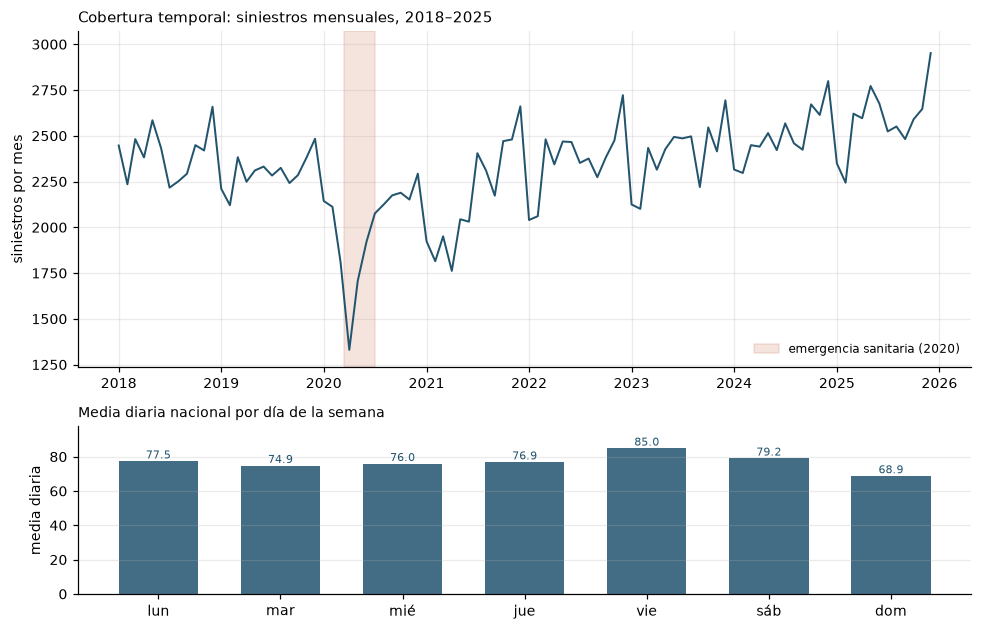

In [13]:
mensual = serie_nac.resample("MS").sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.8), height_ratios=[2, 1])
ax1.plot(mensual.index, mensual.to_numpy(), color="#22546e", lw=1.3)
ax1.axvspan(pd.Timestamp("2020-03-13"), pd.Timestamp("2020-06-30"),
            color="#c96a4a", alpha=0.18, label="emergencia sanitaria (2020)")
tope = mensual.max() * 1.04
ax1.set_ylim(mensual.min() * 0.93, tope)
ax1.set_ylabel("siniestros por mes")
ax1.set_title("Cobertura temporal: siniestros mensuales, 2018–2025", loc="left", fontsize=10)
ax1.legend(loc="lower right", fontsize=8, frameon=False)

perfil = serie_nac.groupby(serie_nac.index.dayofweek).mean()
ax2.bar(range(7), perfil.to_numpy(), color="#22546e", alpha=0.85, width=0.65)
ax2.set_xticks(range(7), ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"])
ax2.set_ylim(0, perfil.max() * 1.15)
for x, v in enumerate(perfil.to_numpy()):
    ax2.text(x, v + 1.5, f"{v:.1f}", ha="center", fontsize=7.5, color="#22546e")
ax2.set_ylabel("media diaria")
ax2.set_title("Media diaria nacional por día de la semana", loc="left", fontsize=9)
ax2.grid(axis="x", visible=False)
fig.tight_layout()
guardar_figura(fig, "fig1_cobertura_temporal")
plt.show()

Los ocho años (**2.922 días, 2018-01-01 a 2025-12-31**) están completos y sin huecos. El
volumen anual es estable salvo **2020, con 24.031 siniestros (−13,0 % respecto de 2019)** y una
caída concentrada en abril (1.331 frente a una media de 2.298 en los abriles restantes). Desde
2021 la serie se recupera y crece de forma sostenida hasta 2025 (31.005, el máximo del período).

Esto tiene una consecuencia sobre el diseño de evaluación que conviene registrar en el informe:
**el período de entrenamiento contiene una anomalía estructural** —la restricción de movilidad
de 2020— que no vuelve a aparecer en validación ni en test. No es un error de datos y no se
corrige; se declara como fuente de discrepancia entre particiones y como argumento para no
interpretar una caída de desempeño entre validación y test como sobreajuste sin antes descartar
el cambio de régimen.

### 3.2 División cronológica del período de modelado

Las particiones son **cronológicas, nunca aleatorias**: con variables de rezago, un corte al
azar le filtra el futuro al modelo y las métricas salen infladas (guía 6.2). El período de
modelado empieza en 2019 porque 2018 se consume como calentamiento de las medias móviles de
365 días.

El reparto sigue la proporción **70 / 10 / 20**: se reserva el 20 % final como conjunto de
prueba —que no se usa para ajustar nada— y el 80 % restante se divide en 70 % de entrenamiento
y 10 % de validación. Los cortes se calculan sobre el eje de días, de modo que las proporciones
se cumplan exactamente; no se los redondea a fin de año.

In [14]:
fechas_modelo = fechas[fechas.year >= ANIO_INICIO]
n_modelo = len(fechas_modelo)
n_train = round(PROP_TRAIN * n_modelo)
n_valid = round(PROP_VALID * n_modelo)

PARTICIONES = {
    "entrenamiento": (fechas_modelo[0], fechas_modelo[n_train - 1]),
    "validación": (fechas_modelo[n_train], fechas_modelo[n_train + n_valid - 1]),
    "test (reservado)": (fechas_modelo[n_train + n_valid], fechas_modelo[-1]),
}
CORTE_TRAIN = PARTICIONES["entrenamiento"][1]
CORTE_VALID = PARTICIONES["validación"][1]

en_modelo = df["Fecha"] >= fechas_modelo[0]
sin_modelo = int(en_modelo.sum())

filas = []
for nombre, (desde, hasta) in PARTICIONES.items():
    dias = (hasta - desde).days + 1
    siniestros = int(((df["Fecha"] >= desde) & (df["Fecha"] <= hasta)).sum())
    filas.append({
        "partición": nombre,
        "desde": f"{desde:%Y-%m-%d}",
        "hasta": f"{hasta:%Y-%m-%d}",
        "días": dias,
        "pct_días": 100 * dias / n_modelo,
        "siniestros": siniestros,
        "pct_siniestros": 100 * siniestros / sin_modelo,
        "media_diaria": siniestros / dias,
        "filas_panel": dias * zonas_diagnostico,
    })

particiones = pd.DataFrame(filas).round({"pct_días": 1, "pct_siniestros": 1, "media_diaria": 1})
guardar_tabla(particiones, "10_particiones")
assert particiones["días"].sum() == n_modelo, "las particiones no cubren el período de modelado"
print(f"período de modelado: {fechas_modelo[0]:%Y-%m-%d} → {fechas_modelo[-1]:%Y-%m-%d} "
      f"({n_modelo:,} días · {sin_modelo:,} siniestros)")

[tabla]  experiments\diagnostico_datos\tablas\10_particiones.csv


,partición,desde,hasta,días,pct_días,siniestros,pct_siniestros,media_diaria,filas_panel
0,entrenamiento,2019-01-01,2023-11-25,1790,70.0,131760,67.3,73.6,33091730
1,validación,2023-11-26,2024-08-07,256,10.0,20666,10.6,80.7,4732672
2,test (reservado),2024-08-08,2025-12-31,511,20.0,43416,22.2,85.0,9446857


período de modelado: 2019-01-01 → 2025-12-31 (2,557 días · 195,842 siniestros)


[figura] experiments\diagnostico_datos\figuras\fig2_particiones.png


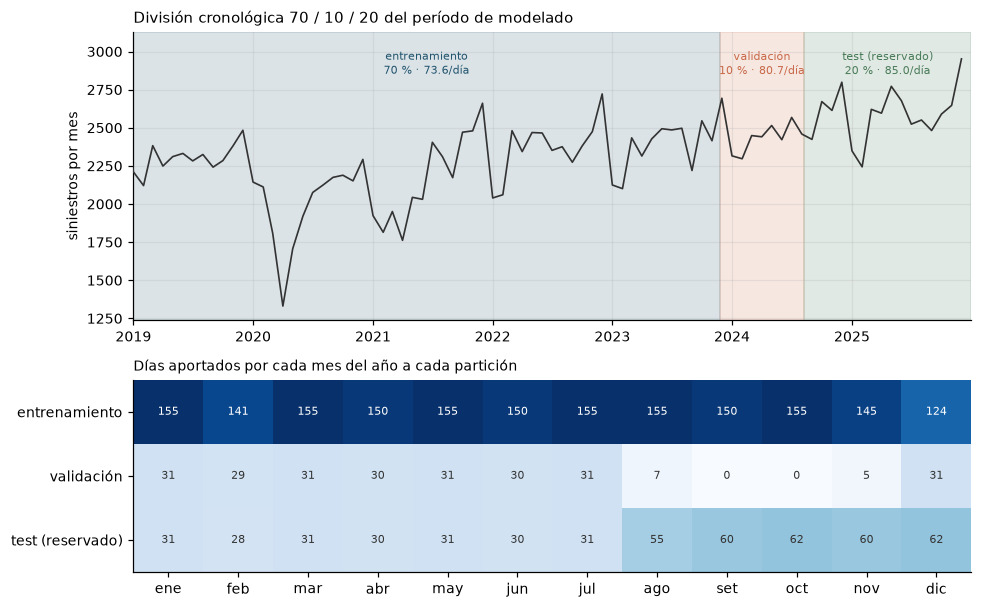

In [15]:
COLOR_PART = {"entrenamiento": "#22546e", "validación": "#c96a4a", "test (reservado)": "#4a7c59"}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5.6), height_ratios=[3, 2])
ax1.plot(mensual.index, mensual.to_numpy(), color="#333", lw=1.1, zorder=3)
for i, (nombre, (desde, hasta)) in enumerate(PARTICIONES.items()):
    fila = particiones.iloc[i]
    ax1.axvspan(desde, hasta, color=COLOR_PART[nombre], alpha=0.16)
    ax1.text(desde + (hasta - desde) / 2, mensual.max() * 1.02,
             f"{nombre}\n{fila['pct_días']:.0f} % · {fila['media_diaria']:.1f}/día",
             ha="center", va="top", fontsize=7.5, color=COLOR_PART[nombre])
ax1.set_ylim(mensual.min() * 0.93, mensual.max() * 1.06)
ax1.set_xlim(fechas_modelo[0], fechas_modelo[-1])
ax1.set_ylabel("siniestros por mes")
ax1.set_title("División cronológica 70 / 10 / 20 del período de modelado", loc="left", fontsize=10)

# Composición estacional: cuántos días de cada mes aporta cada partición
comp = np.zeros((3, 12), dtype=int)
for i, (desde, hasta) in enumerate(PARTICIONES.values()):
    meses = pd.date_range(desde, hasta, freq="D").month
    comp[i] = np.bincount(meses, minlength=13)[1:]

ax2.imshow(comp, aspect="auto", cmap="Blues", vmin=0, vmax=comp.max())
for i in range(3):
    for j in range(12):
        ax2.text(j, i, comp[i, j], ha="center", va="center", fontsize=7.5,
                 color="white" if comp[i, j] > comp.max() * 0.55 else "#333")
ax2.set_yticks(range(3), list(PARTICIONES))
ax2.set_xticks(range(12), ["ene", "feb", "mar", "abr", "may", "jun",
                           "jul", "ago", "set", "oct", "nov", "dic"])
ax2.set_title("Días aportados por cada mes del año a cada partición", loc="left", fontsize=9)
ax2.grid(visible=False)
fig.tight_layout()
guardar_figura(fig, "fig2_particiones")
plt.show()

Los cortes caen en **2023-11-25** (fin de entrenamiento) y **2024-08-07** (fin de validación).
Las proporciones por días son exactas —70,0 / 10,0 / 20,0—, pero el reparto de siniestros no lo
es: 67,3 % / 10,6 % / 22,2 %. La diferencia refleja la tendencia creciente de la serie, visible
también en la media diaria de cada partición: **73,6 en entrenamiento, 80,7 en validación y
85,0 en test**. El modelo se entrena, por tanto, sobre un régimen de siniestralidad algo más
bajo que aquel sobre el que se lo evalúa.

**Advertencia sobre la composición estacional.** Cumplir 70/10/20 con exactitud obliga a cortar
a mitad de año, y eso deja las particiones con distinta mezcla de meses: la validación abarca
256 días entre noviembre y agosto y **no contiene ningún día de setiembre ni de octubre**,
mientras el test cubre los doce meses e incluye dos diciembres —el mes de mayor siniestralidad,
85,7 siniestros diarios de media—. La consecuencia práctica es que **el nivel del error de
validación y el de test no son directamente comparables**: parte de la diferencia entre ambos
vendrá de que son épocas del año distintas, no de que el modelo generalice peor. La comparación
*entre modelos dentro de la validación* sigue siendo válida, que es para lo que la validación se
usa. Si el equipo prefiere particiones estacionalmente homogéneas, la alternativa es cortar por
años completos, a costa de no alcanzar exactamente las proporciones pedidas.

**Nota de coherencia:** `analisis_inicial.ipynb` todavía parte por años completos
(2019–2023 / 2024 / 2025 ≈ 71/14/14) y escribe las *features* particionadas por año. Debe
alinearse con estos cortes antes del Entregable 2; al cortar dentro del año, el filtro de
partición pasa a ser por fecha y no por directorio.

### 3.3 Cobertura territorial

In [16]:
terr = pd.DataFrame({
    "siniestros": df.groupby("Departamento").size(),
    "zonas": df.groupby("Departamento")[["celda_x", "celda_y"]].apply(
        lambda g: g.groupby(["celda_x", "celda_y"]).ngroups
    ),
})
terr["pct_siniestros"] = (100 * terr["siniestros"] / N).round(1)
terr["siniestros_por_zona"] = (terr["siniestros"] / terr["zonas"]).round(1)
terr = terr.sort_values("siniestros", ascending=False)
guardar_tabla(terr.reset_index(), "11_cobertura_departamental")

[tabla]  experiments\diagnostico_datos\tablas\11_cobertura_departamental.csv


,Departamento,siniestros,zonas,pct_siniestros,siniestros_por_zona
0,MONTEVIDEO,62427,1167,27.8,53.5
1,CANELONES,28972,2715,12.9,10.7
2,MALDONADO,21127,1446,9.4,14.6
3,COLONIA,12603,1443,5.6,8.7
4,PAYSANDU,12085,893,5.4,13.5
5,SALTO,10849,749,4.8,14.5
6,SORIANO,8712,841,3.9,10.4
7,SAN JOSE,8302,990,3.7,8.4
8,TACUAREMBO,8214,792,3.7,10.4
9,CERRO LARGO,7033,804,3.1,8.7


In [17]:
zonas_obs = df.groupby(["celda_x", "celda_y"]).size().rename("n_hist")
area_cubierta = len(zonas_obs) * (TAM_CELDA / 1000) ** 2

alcance = pd.DataFrame(
    [
        ("celdas de 500 m con al menos un siniestro", f"{len(zonas_obs):,}"),
        ("superficie cubierta por esas celdas", f"{area_cubierta:,.0f} km²"),
        ("proporción del territorio continental", f"{100 * area_cubierta / SUPERFICIE_UY_KM2:.1f} %"),
        ("departamentos con presencia", f"{df['Departamento'].nunique()} de 19"),
        ("siniestros en Montevideo", f"{100 * (df['Departamento'] == 'MONTEVIDEO').mean():.1f} %"),
    ],
    columns=["indicador", "valor"],
)
guardar_tabla(alcance, "12_alcance_territorial")

[tabla]  experiments\diagnostico_datos\tablas\12_alcance_territorial.csv


,indicador,valor
0,celdas de 500 m con al menos un siniestro,"18,487"
1,superficie cubierta por esas celdas,"4,622 km²"
2,proporción del territorio continental,2.6 %
3,departamentos con presencia,19 de 19
4,siniestros en Montevideo,27.8 %


[figura] experiments\diagnostico_datos\figuras\fig3_cobertura_territorial.png


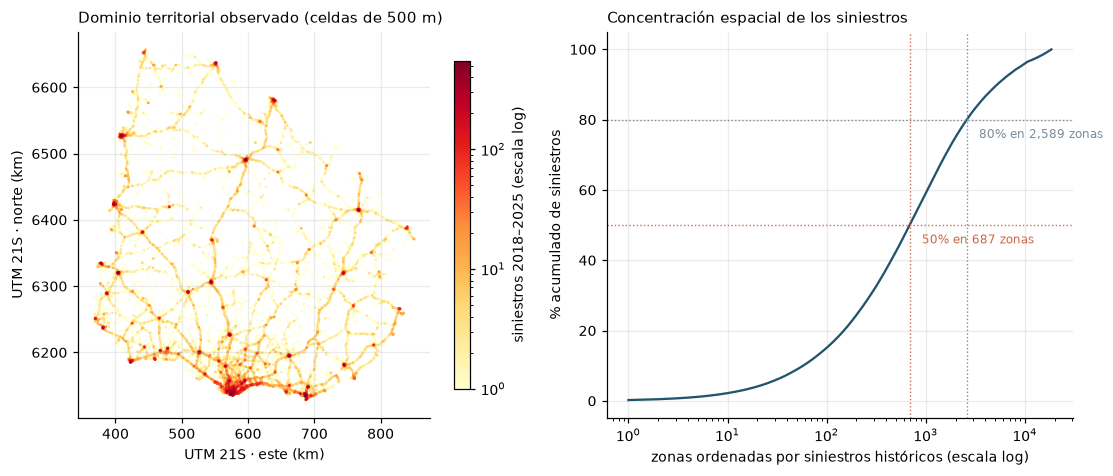

In [18]:
centros_x = (zonas_obs.index.get_level_values(0) * TAM_CELDA + TAM_CELDA / 2) / 1000
centros_y = (zonas_obs.index.get_level_values(1) * TAM_CELDA + TAM_CELDA / 2) / 1000
orden = np.argsort(zonas_obs.to_numpy())  # las zonas densas se dibujan encima

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4))
sc = ax1.scatter(centros_x.to_numpy()[orden], centros_y.to_numpy()[orden],
                 c=zonas_obs.to_numpy()[orden], s=2.5, cmap="YlOrRd",
                 norm="log", linewidths=0)
ax1.set_aspect("equal")
ax1.set_xlabel("UTM 21S · este (km)")
ax1.set_ylabel("UTM 21S · norte (km)")
ax1.set_title("Dominio territorial observado (celdas de 500 m)", loc="left", fontsize=10)
fig.colorbar(sc, ax=ax1, label="siniestros 2018–2025 (escala log)", shrink=0.85)

acum = zonas_obs.sort_values(ascending=False).cumsum().to_numpy() / N
ax2.plot(np.arange(1, len(acum) + 1), 100 * acum, color="#22546e", lw=1.5)
for pct, color in ((0.5, "#c96a4a"), (0.8, "#7a8b99")):
    k = int((acum < pct).sum() + 1)
    ax2.axhline(100 * pct, color=color, ls=":", lw=0.9)
    ax2.axvline(k, color=color, ls=":", lw=0.9)
    ax2.annotate(f"{pct:.0%} en {k:,} zonas", (k, 100 * pct), textcoords="offset points",
                 xytext=(8, -12), fontsize=8, color=color)
ax2.set_xscale("log")
ax2.set_xlabel("zonas ordenadas por siniestros históricos (escala log)")
ax2.set_ylabel("% acumulado de siniestros")
ax2.set_title("Concentración espacial de los siniestros", loc="left", fontsize=10)
fig.tight_layout()
guardar_figura(fig, "fig3_cobertura_territorial")
plt.show()

Los 19 departamentos están representados y el dominio dibuja el país: la red vial nacional, las
capitales departamentales y el eje costero. Pero la cobertura es **muy desigual y muy
concentrada**:

- Las 18.487 celdas observadas suman **4.622 km², el 2,6 % del territorio continental**. El
  modelo sólo puede pronunciarse sobre esa fracción; el resto del país no es «riesgo bajo», es
  **territorio no observado**.
- **Montevideo concentra el 27,8 % de los siniestros en 1.167 zonas** (53,5 siniestros por zona,
  cinco veces el promedio nacional), mientras departamentos como Rocha o Florida reparten menos
  de 6 siniestros por zona.
- La mitad de los siniestros ocurre en **687 zonas** y el 80 % en **2.589**, sobre 18.487.

La lectura para el modelo es que el problema efectivo es **muy heterogéneo en soporte**: unas
pocas zonas urbanas con serie densa y una larga cola de zonas con dos o tres eventos en ocho
años, donde ningún método puede estimar una tasa con precisión. Es el argumento central para
evaluar el desempeño **por estrato de soporte** y no sólo de forma agregada.

### 3.4 Cobertura de la unidad de análisis: el panel día × zona

El panel completo es el producto cartesiano días × zonas. Su densidad determina de qué está
hecho realmente el conjunto de entrenamiento.

In [19]:
# Matriz densa días × zonas (int16, ~108 MB): base de todos los cálculos siguientes
catalogo = zonas_obs.reset_index().reset_index(names="zona_id")
df = df.merge(catalogo[["celda_x", "celda_y", "zona_id"]], on=["celda_x", "celda_y"], how="left")
assert df["zona_id"].notna().all(), "hay siniestros sin zona asignada"

observado = df.groupby(["Fecha", "zona_id"]).size()
M = np.zeros((len(fechas), len(catalogo)), dtype="int16")
M[fechas.get_indexer(observado.index.get_level_values(0)),
  observado.index.get_level_values(1).to_numpy()] = observado.to_numpy()
assert M.sum() == N, "se perdieron siniestros al armar el panel"

celdas_panel = M.size
no_cero = int((M > 0).sum())
panel = pd.DataFrame(
    [
        ("filas del panel (días × zonas)", f"{celdas_panel:,}"),
        ("filas con al menos un siniestro", f"{no_cero:,}"),
        ("densidad (filas no nulas)", f"{100 * no_cero / celdas_panel:.3f} %"),
        ("ceros", f"{100 * (1 - no_cero / celdas_panel):.3f} %"),
        ("media de siniestros por fila", f"{M.mean():.6f}"),
        ("máximo en una fila", f"{M.max()}"),
    ],
    columns=["indicador", "valor"],
)
guardar_tabla(panel, "13_panel_dia_zona")

[tabla]  experiments\diagnostico_datos\tablas\13_panel_dia_zona.csv


,indicador,valor
0,filas del panel (días × zonas),"54,019,014"
1,filas con al menos un siniestro,"218,778"
2,densidad (filas no nulas),0.405 %
3,ceros,99.595 %
4,media de siniestros por fila,0.004160
5,máximo en una fila,11


In [20]:
# Soporte histórico por zona: cuántas zonas y qué parte de los siniestros sobrevive a cada umbral
n_hist = M.sum(axis=0)
filas = []
for k in (1, 5, 10, 25, 50, 100):
    sel = n_hist >= k
    sub = M[:, sel]
    filas.append((
        k, int(sel.sum()), 100 * sel.sum() / len(n_hist),
        int(sub.sum()), 100 * sub.sum() / N,
        100 * (sub > 0).mean(),
    ))
soporte = pd.DataFrame(filas, columns=[
    "min_siniestros_zona", "zonas", "pct_zonas", "siniestros", "pct_siniestros", "pct_dias_con_evento",
]).round(2)
guardar_tabla(soporte, "14_soporte_por_zona")

[tabla]  experiments\diagnostico_datos\tablas\14_soporte_por_zona.csv


,min_siniestros_zona,zonas,pct_zonas,siniestros,pct_siniestros,pct_dias_con_evento
0,1,18487,100.00,224694,100.00,0.41
1,5,5458,29.52,203268,90.46,1.24
2,10,3448,18.65,190165,84.63,1.83
3,25,1908,10.32,166556,74.13,2.89
4,50,1113,6.02,138611,61.69,4.10
5,100,520,2.81,97466,43.38,6.12


El panel tiene **54.019.014 filas y sólo el 0,405 % es distinto de cero**: 99,6 % de ceros. Esa
cifra es el hecho dominante de todo el proyecto y condiciona tres decisiones que ya están
tomadas en `analisis_inicial.ipynb` y que este diagnóstico respalda: el submuestreo de ceros
con pesos, el objetivo de tipo conteo y la elección de métricas que no premien predecir siempre
cero.

La tabla de soporte muestra el intercambio disponible: quedarse con las **5.458 zonas** que
tienen al menos 5 siniestros históricos (29,5 % de las zonas) conserva el **90,5 % de los
siniestros** y triplica la densidad (1,24 % de días con evento); exigir 50 siniestros deja
1.113 zonas (6 %) con el 61,7 % de los eventos y una densidad del 4,1 %. **Ningún umbral
razonable convierte el problema en uno denso**: la escasez no es un defecto de la fuente, es la
naturaleza del fenómeno a esta granularidad.

### 3.5 Estabilidad del universo de zonas entre particiones

El catálogo de zonas se define como «celdas con al menos un siniestro histórico», calculado
sobre los ocho años. Conviene comprobar qué implica eso cuando el panel se parte
cronológicamente.

In [21]:
# Índices de fila del panel que corresponden a cada partición cronológica
idx_part = {nombre: np.flatnonzero((fechas >= desde) & (fechas <= hasta))
            for nombre, (desde, hasta) in PARTICIONES.items()}
activas = {nombre: set(np.flatnonzero(M[idx].sum(axis=0) > 0)) for nombre, idx in idx_part.items()}
z_train = activas["entrenamiento"]

filas = [
    ("zonas del catálogo (2018–2025)", f"{len(catalogo):,}", ""),
    ("zonas activas en entrenamiento", f"{len(z_train):,}",
     f"{100 * len(z_train) / len(catalogo):.1f} % del catálogo"),
]
for nombre in ("validación", "test (reservado)"):
    nuevas = np.array(sorted(activas[nombre] - z_train), dtype=int)
    idx = idx_part[nombre]
    total = int(M[idx].sum())
    huerfanos = int(M[np.ix_(idx, nuevas)].sum()) if len(nuevas) else 0
    filas += [
        (f"zonas activas en {nombre}", f"{len(activas[nombre]):,}",
         f"{len(nuevas):,} sin historial en entrenamiento ({100 * len(nuevas) / len(activas[nombre]):.1f} %)"),
        (f"siniestros de {nombre} en zonas sin historial", f"{huerfanos:,}",
         f"{100 * huerfanos / total:.1f} % de la partición"),
    ]

estabilidad = pd.DataFrame(filas, columns=["indicador", "valor", "detalle"])
guardar_tabla(estabilidad, "15_estabilidad_zonas")

[tabla]  experiments\diagnostico_datos\tablas\15_estabilidad_zonas.csv


,indicador,valor,detalle
0,zonas del catálogo (2018–2025),"18,487",
1,zonas activas en entrenamiento,"14,807",80.1 % del catálogo
2,zonas activas en validación,"5,773",922 sin historial en entrenamiento (16.0 %)
3,siniestros de validación en zonas sin historial,972,4.7 % de la partición
4,zonas activas en test (reservado),"8,061","1,787 sin historial en entrenamiento (22.2 %)"
5,siniestros de test (reservado) en zonas sin hi...,"1,991",4.6 % de la partición


Dos hallazgos, uno operativo y otro metodológico.

**Operativo.** De las 8.061 zonas con siniestros en el tramo de test, **1.787 (22,2 %) no
registraron ninguno durante el entrenamiento**; en validación son 922 de 5.773 (16,0 %). Sobre
ellas el modelo predice con historial vacío: sus rezagos y medias móviles valen cero y sólo
puede aportar el efecto de calendario. Concentran el **4,6 % de los siniestros del test** y el
4,7 % de los de validación, proporción que actúa como cota inferior del error inevitable para
cualquier modelo basado en historial de zona. Debe declararse al interpretar los resultados y
tratarse como un estrato propio en el análisis de errores.

**Metodológico.** El catálogo de zonas se construye con los ocho años, **test incluido**: la
existencia de una zona en el panel usa información posterior al corte de entrenamiento. Es una
fuga leve —afecta al universo de filas, no a ninguna variable predictora— pero real, y hay que
declararla en lugar de dejarla implícita. Su efecto es *conservador*: agrega al panel zonas casi
siempre vacías, lo que puede mejorar artificialmente cualquier métrica promediada sobre celdas.
La alternativa limpia es definir el catálogo sólo con entrenamiento y tratar las zonas nuevas
como fuera de dominio; queda registrada como decisión a revisar antes de la evaluación final.

### 3.6 Cobertura de las variables exógenas previstas

La propuesta declara dos fuentes exógenas además de los siniestros: calendario de feriados y
clima histórico de Open-Meteo. Se verifica qué hay efectivamente disponible en el repositorio.

In [22]:
# ¿Hay algún archivo de clima en data/? (la caché de Open-Meteo del PID todavía no se integró)
patrones = ("clima", "weather", "meteo", "openmeteo")
archivos_datos = [p for p in (RAIZ / "data").rglob("*") if p.is_file() and p.suffix in {".csv", ".parquet", ".json"}]
clima = [p for p in archivos_datos if any(t in p.name.lower() for t in patrones)]

print(f"archivos de datos en data/: {len(archivos_datos)}")
for p in sorted(archivos_datos):
    print(f"  {p.relative_to(RAIZ)}  ({p.stat().st_size / 1e6:.1f} MB)")
print(f"\narchivos de clima detectados: {len(clima) if clima else 'ninguno'}")

archivos de datos en data/: 10
  data\processed\features\anio=2019\datos.parquet  (2.5 MB)
  data\processed\features\anio=2020\datos.parquet  (3.2 MB)
  data\processed\features\anio=2021\datos.parquet  (4.3 MB)
  data\processed\features\anio=2022\datos.parquet  (4.7 MB)
  data\processed\features\anio=2023\datos.parquet  (3.1 MB)
  data\processed\features\anio=2024\datos.parquet  (3.0 MB)
  data\processed\features\anio=2025\datos.parquet  (3.5 MB)
  data\processed\panel_diario_zona.parquet  (9.0 MB)
  data\processed\zonas.parquet  (0.1 MB)
  data\raw\uru_siniestros_unificado.csv  (26.2 MB)

archivos de clima detectados: ninguno


In [23]:
# Feriados: la categoría por defecto de `holidays` para Uruguay omite los feriados no laborables
anios_rango = range(fechas.year.min(), fechas.year.max() + 1)
fer_public = holidays.country_holidays("UY", years=anios_rango)
fer_todos = holidays.country_holidays("UY", years=anios_rango, categories=("bank", "public"))
solo_bank = {d for d in fer_todos if d not in fer_public}

dia = pd.Series(serie_nac.index.date, index=serie_nac.index)
es_public = dia.isin(fer_public)
es_bank = dia.isin(solo_bank)

feriados = pd.DataFrame(
    [
        ("feriados 'public' (los que usa la feature actual)", int(es_public.sum()), serie_nac[es_public].mean()),
        ("feriados 'bank' omitidos por la feature", int(es_bank.sum()), serie_nac[es_bank].mean()),
        ("días ordinarios", int((~es_public & ~es_bank).sum()), serie_nac[~es_public & ~es_bank].mean()),
    ],
    columns=["grupo", "días", "media_diaria_nacional"],
).round({"media_diaria_nacional": 1})
guardar_tabla(feriados, "16_feriados")

detalle = (
    pd.DataFrame({"nombre": [fer_todos[d] for d in sorted(solo_bank)],
                  "siniestros": serie_nac[es_bank].to_numpy()})
    .groupby("nombre")["siniestros"].agg(dias="size", media="mean").round(1)
    .sort_values("media")
)
guardar_tabla(detalle.reset_index(), "17_feriados_omitidos")

[tabla]  experiments\diagnostico_datos\tablas\16_feriados.csv


,grupo,días,media_diaria_nacional
0,feriados 'public' (los que usa la feature actual),41,64.8
1,feriados 'bank' omitidos por la feature,104,65.0
2,días ordinarios,2777,77.5


[tabla]  experiments\diagnostico_datos\tablas\17_feriados_omitidos.csv


,nombre,dias,media
0,Desembarco de los 33 Orientales,8,57.4
1,Batalla de Las Piedras,8,62.8
2,Semana de Turismo,40,64.6
3,Día de la Diversidad Cultural,8,64.8
4,Carnaval,16,65.1
5,Día de los Difuntos,8,68.0
6,Día de los Niños,8,68.4
7,Natalicio de Artigas,8,70.5


**Clima: no está.** `data/` sólo contiene el CSV de siniestros y los derivados del panel; no
hay ninguna caché de Open-Meteo en el repositorio. La variable climática está **prevista pero no
incorporada**, y así debe figurar en el informe: hasta que la caché del PID se integre y se
verifique su cobertura por zona y fecha, ningún resultado puede atribuirse al clima.

**Feriados: la definición actual está incompleta.** `holidays.country_holidays("UY")` devuelve
por defecto sólo la categoría `public`: **41 días en ocho años, 5 por año**. Los feriados no
laborables (Carnaval, Semana de Turismo, 6 de enero, 19 de abril, 18 de mayo, 19 de junio,
12 de octubre, 2 de noviembre) quedan en la categoría `bank` y hoy **no** los marca la feature
`es_feriado` de `analisis_inicial.ipynb`.

La omisión importa porque esos días se comportan igual que los feriados que sí se marcan:
**65,0 siniestros diarios de media en los 104 días `bank`** frente a **64,8 en los 41 días
`public`** y **77,5 en los días ordinarios**. Es decir, la feature actual identifica sólo 41 de
los 145 días con caída sistemática de siniestralidad —el 28 %— y trata a los 104 restantes como
días normales, entre ellos los 40 días de Semana de Turismo, el período de movilidad más atípico
del año. **Corrección propuesta:** construir `es_feriado` con `categories=("bank", "public")` y,
dado que Semana de Turismo y Carnaval son períodos y no días sueltos, evaluar además una variable
de «período especial».

## 4. Adecuación

Las secciones anteriores describen los datos. Ésta pregunta otra cosa: **¿alcanzan para el
problema que el proyecto se propuso?** El objetivo declarado es pronosticar la cantidad esperada
de siniestros por zona y período para señalar en un mapa las zonas y períodos de mayor riesgo.

*Sobre qué datos se calcula esta sección.* Las cifras descriptivas usan el histórico completo,
porque caracterizar el fenómeno con más años es preferible y ningún parámetro se ajusta aquí.
Donde el análisis **orienta una decisión de modelado** —la ausencia de señal temporal de la
sección 4.3, que fija la línea base— se repite además restringido al tramo de entrenamiento, y
se declara si la conclusión cambia. El test no se usa para decidir nada.

### 4.1 La variable objetivo

In [24]:
valores, cuentas = np.unique(M[M > 0], return_counts=True)
dist = pd.DataFrame({"siniestros_en_la_celda": valores, "celdas": cuentas})
dist["pct_de_celdas_positivas"] = (100 * dist["celdas"] / dist["celdas"].sum()).round(2)
guardar_tabla(dist, "18_distribucion_objetivo")

media_panel = float(M.mean())
var_panel = float(M.var())
objetivo = pd.DataFrame(
    [
        ("media (siniestros / día / zona)", f"{media_panel:.6f}"),
        ("varianza", f"{var_panel:.6f}"),
        ("índice de dispersión (varianza / media)", f"{var_panel / media_panel:.3f}"),
        ("celdas positivas con exactamente 1 siniestro", f"{100 * cuentas[0] / cuentas.sum():.1f} %"),
        ("máximo observado", f"{int(M.max())}"),
    ],
    columns=["indicador", "valor"],
)
guardar_tabla(objetivo, "19_dispersion_objetivo")

[tabla]  experiments\diagnostico_datos\tablas\18_distribucion_objetivo.csv


,siniestros_en_la_celda,celdas,pct_de_celdas_positivas
0,1,213095,97.40
1,2,5477,2.50
2,3,193,0.09
3,4,9,0.00
4,5,2,0.00
5,9,1,0.00
6,11,1,0.00


[tabla]  experiments\diagnostico_datos\tablas\19_dispersion_objetivo.csv


,indicador,valor
0,media (siniestros / día / zona),0.004160
1,varianza,0.004373
2,índice de dispersión (varianza / media),1.051
3,celdas positivas con exactamente 1 siniestro,97.4 %
4,máximo observado,11


El índice de dispersión del panel es **1,05**: la varianza casi iguala a la media, que es lo que
caracteriza a un proceso de Poisson. No hay sobredispersión que justifique una binomial negativa
ni exceso de ceros respecto de lo que la propia Poisson predice —los ceros abundan porque la tasa
es bajísima, no porque exista un mecanismo adicional que los genere—. Esto **respalda usar un
objetivo Poisson** (verosimilitud/desvianza de Poisson) en lugar de un error cuadrático sobre el
conteo.

El segundo hecho es más incómodo: **el 97,4 % de las celdas con siniestro tienen exactamente
uno**, y sólo 206 de 218.778 superan los dos. A esta granularidad la variable objetivo es casi
binaria. En consecuencia, *acertar el conteo* de una celda concreta no es un objetivo alcanzable
ni informativo: lo estimable es la **intensidad** (el valor esperado), y la evaluación tiene que
medir calibración y ordenamiento de riesgo, no exactitud puntual. Este punto condiciona la
elección de métricas del Entregable 2.

### 4.2 ¿Es adecuada la granularidad elegida?

La celda de 500 m y el paso diario son una decisión, no un dato. Se mide cuánto cambian la
densidad y el tamaño del problema al variar ambos ejes, para poder justificar la elección con
evidencia en vez de por costumbre.

In [25]:
n_dias = len(fechas)
sweep = []
for tam in (500, 1000, 2000, 5000):
    cx = df["X"] // tam
    cy = df["Y"] // tam
    n_zonas = pd.MultiIndex.from_arrays([cx, cy]).nunique()
    for etiqueta, periodo, n_per in (
        ("diaria", df["Fecha"].dt.to_period("D"), n_dias),
        ("semanal", df["Fecha"].dt.to_period("W"), int(np.ceil(n_dias / 7))),
        ("mensual", df["Fecha"].dt.to_period("M"), df["Fecha"].dt.to_period("M").nunique()),
    ):
        conteos = df.groupby([periodo, cx, cy]).size()
        filas_tot = n_zonas * n_per
        sweep.append({
            "celda_m": tam, "granularidad": etiqueta, "zonas": n_zonas, "periodos": n_per,
            "filas_panel": filas_tot, "pct_no_cero": 100 * len(conteos) / filas_tot,
            "media_por_fila": len(df) / filas_tot, "max_por_fila": int(conteos.max()),
        })

sweep = pd.DataFrame(sweep).round({"pct_no_cero": 3, "media_por_fila": 4})
guardar_tabla(sweep, "20_granularidad")
print(sweep.pivot(index="celda_m", columns="granularidad", values="pct_no_cero").to_string())

[tabla]  experiments\diagnostico_datos\tablas\20_granularidad.csv


,celda_m,granularidad,zonas,periodos,filas_panel,pct_no_cero,media_por_fila,max_por_fila
0,500,diaria,18487,2922,54019014,0.405,0.0042,11
1,500,semanal,18487,418,7727566,2.537,0.0291,11
2,500,mensual,18487,96,1774752,8.274,0.1266,18
3,1000,diaria,11633,2922,33991626,0.616,0.0066,11
4,1000,semanal,11633,418,4862594,3.302,0.0462,14
5,1000,mensual,11633,96,1116768,8.975,0.2012,38
6,2000,diaria,6800,2922,19869600,0.951,0.0113,11
7,2000,semanal,6800,418,2842400,4.097,0.0791,22
8,2000,mensual,6800,96,652800,10.027,0.3442,71
9,5000,diaria,2894,2922,8456268,1.767,0.0266,13


granularidad  diaria  mensual  semanal
celda_m                               
500            0.405    8.274    2.537
1000           0.616    8.975    3.302
2000           0.951   10.027    4.097
5000           1.767   14.373    6.185


[figura] experiments\diagnostico_datos\figuras\fig4_granularidad.png


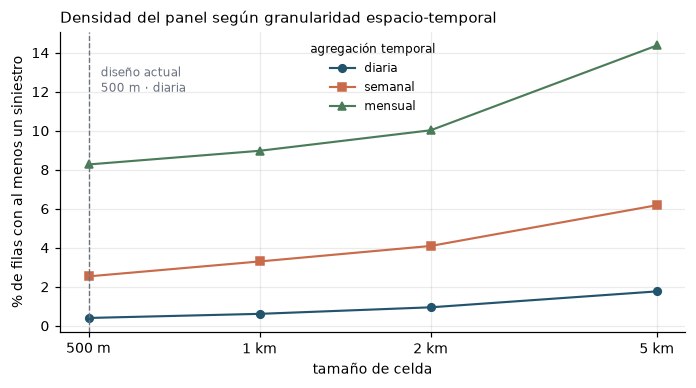

In [26]:
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for etiqueta, color, marca in (("diaria", "#22546e", "o"), ("semanal", "#c96a4a", "s"), ("mensual", "#4a7c59", "^")):
    sub = sweep[sweep["granularidad"] == etiqueta]
    ax.plot(sub["celda_m"], sub["pct_no_cero"], marker=marca, color=color, label=etiqueta, lw=1.4, ms=5)
ax.axvline(TAM_CELDA, color="#6b7280", ls="--", lw=0.9)
ax.annotate("diseño actual\n500 m · diaria", (TAM_CELDA, 12), fontsize=8, color="#6b7280",
            textcoords="offset points", xytext=(8, 0))
ax.set_xscale("log")
ax.set_xticks([500, 1000, 2000, 5000], ["500 m", "1 km", "2 km", "5 km"])
ax.xaxis.set_minor_locator(plt.NullLocator())   # el log añade marcas que aquí sólo estorban
ax.set_xlabel("tamaño de celda")
ax.set_ylabel("% de filas con al menos un siniestro")
ax.set_title("Densidad del panel según granularidad espacio-temporal", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8, title="agregación temporal", title_fontsize=8)
fig.tight_layout()
guardar_figura(fig, "fig4_granularidad")
plt.show()

La escasez **no se resuelve agrandando la celda**. Pasar de 500 m a 5 km multiplica el área por
100 y la densidad diaria sólo sube de 0,41 % a 1,77 %; hay que llegar a 5 km **mensuales** para
alcanzar un 14,4 % de filas no vacías, a costa de perder por completo la resolución que el
producto necesita: un mapa de celdas de 5 km con horizonte mensual no orienta ninguna decisión
operativa de fiscalización.

Con esta evidencia, la elección de **500 m × día se sostiene**, pero por una razón que hay que
enunciar bien: no porque produzca un panel cómodo, sino porque es la granularidad que responde
a la pregunta del proyecto, y porque el problema —una vez aceptado que se estima intensidad y no
conteo— es tratable con modelos de conteo y submuestreo de ceros. La agregación semanal a 500 m
(2,54 % de filas no vacías) queda como **alternativa registrada** si el horizonte de uso del
dashboard resultara semanal.

### 4.3 ¿Cuánta señal temporal hay realmente?

La pregunta decisiva para un pronóstico: ¿el pasado reciente de una zona informa sobre su
futuro? Se compara la autocorrelación observada con la que produciría un proceso puramente
aleatorio de la misma intensidad. Sin esa referencia, cualquier correlación pequeña es
ininterpretable.

In [27]:
def autocorr(x: np.ndarray, k: int) -> float:
    a, b = x[:-k], x[k:]
    if a.std() == 0 or b.std() == 0:
        return np.nan
    return float(((a - a.mean()) * (b - b.mean())).mean() / (a.std() * b.std()))


# (a) Serie nacional agregada, antes y después de descontar el calendario
y = np.log(serie_nac.to_numpy(dtype=float))
cal = pd.DataFrame({
    "dow": serie_nac.index.dayofweek, "mes": serie_nac.index.month, "anio": serie_nac.index.year,
}).astype("category")
cal["feriado"] = (es_public | es_bank).to_numpy().astype(int)
D = pd.get_dummies(cal, drop_first=True).astype(float)
D.insert(0, "const", 1.0)
beta, *_ = np.linalg.lstsq(D.to_numpy(), y, rcond=None)
residuo = y - D.to_numpy() @ beta
r2_calendario = 1 - residuo.var() / y.var()

LAGS = (1, 7, 28, 364)
nacional = pd.DataFrame({
    "lag": LAGS,
    "acf_serie_nacional": [autocorr(serie_nac.to_numpy(dtype=float), k) for k in LAGS],
    "acf_residuo_sin_calendario": [autocorr(residuo, k) for k in LAGS],
}).round(3)
guardar_tabla(nacional, "21_autocorrelacion_nacional")
print(f"varianza de log(serie nacional) explicada por el calendario: {r2_calendario:.1%}")

[tabla]  experiments\diagnostico_datos\tablas\21_autocorrelacion_nacional.csv

,lag,acf_serie_nacional,acf_residuo_sin_calendario
0,1,0.392,0.301
1,7,0.384,0.180
2,28,0.350,0.135
3,364,0.315,0.108


varianza de log(serie nacional) explicada por el calendario: 35.3%


In [28]:
# (b) Series por zona, sólo donde hay soporte suficiente para que la ACF signifique algo.
# Se calcula dos veces: sobre todo el histórico (más potencia para describir el fenómeno) y
# sólo sobre entrenamiento, para verificar que la conclusión no depende de mirar el test.
UMBRAL_SOPORTE = 100
zonas_densas = np.flatnonzero(n_hist >= UMBRAL_SOPORTE)

VENTANAS_ACF = {
    "período completo": np.arange(len(fechas)),
    "sólo entrenamiento": idx_part["entrenamiento"],
}

obs_acf, nulo_acf, fano = {}, {}, {}
for ventana, idx in VENTANAS_ACF.items():
    serie = M[np.ix_(idx, zonas_densas)].astype(float)
    obs_acf[ventana] = {k: np.array([autocorr(serie[:, j], k) for j in range(serie.shape[1])])
                        for k in (1, 7)}
    # Referencia nula: Poisson homogéneo con la tasa observada de cada zona en esa ventana
    nulos = {k: [] for k in (1, 7)}
    for tasa in serie.mean(axis=0):
        sim = rng.poisson(tasa, len(idx)).astype(float)
        for k in (1, 7):
            nulos[k].append(autocorr(sim, k))
    nulo_acf[ventana] = {k: np.array(v) for k, v in nulos.items()}
    fano[ventana] = serie.var(axis=0) / serie.mean(axis=0)

filas = []
for ventana in VENTANAS_ACF:
    for k in (1, 7):
        mediana = np.nanmedian(obs_acf[ventana][k])
        p5 = np.nanpercentile(nulo_acf[ventana][k], 5)
        p95 = np.nanpercentile(nulo_acf[ventana][k], 95)
        filas.append((ventana, k, mediana, p5, p95,
                      "dentro de la banda nula" if p5 <= mediana <= p95 else "fuera de la banda nula"))

comparacion = pd.DataFrame(
    filas, columns=["ventana", "lag", "mediana_observada", "nulo_p5", "nulo_p95", "lectura"]
).round(4)
guardar_tabla(comparacion, "22_acf_por_zona_vs_nulo")
print(f"\nzonas evaluadas (>= {UMBRAL_SOPORTE} siniestros): {len(zonas_densas):,}")
for ventana, idx in VENTANAS_ACF.items():
    f = fano[ventana]
    print(f"{ventana:20s} ({len(idx):,} días) — dispersión por zona: mediana {np.median(f):.3f} "
          f"(p10 {np.percentile(f, 10):.3f}, p90 {np.percentile(f, 90):.3f})")

[tabla]  experiments\diagnostico_datos\tablas\22_acf_por_zona_vs_nulo.csv


,ventana,lag,mediana_observada,nulo_p5,nulo_p95,lectura
0,período completo,1,0.0015,-0.0318,0.0316,dentro de la banda nula
1,período completo,7,0.0057,-0.0271,0.0301,dentro de la banda nula
2,sólo entrenamiento,1,-0.0005,-0.0379,0.0388,dentro de la banda nula
3,sólo entrenamiento,7,0.0035,-0.0358,0.0373,dentro de la banda nula



zonas evaluadas (>= 100 siniestros): 520
período completo     (2,922 días) — dispersión por zona: mediana 1.015 (p10 0.977, p90 1.059)
sólo entrenamiento   (1,790 días) — dispersión por zona: mediana 1.009 (p10 0.965, p90 1.065)


[figura] experiments\diagnostico_datos\figuras\fig5_senal_temporal.png


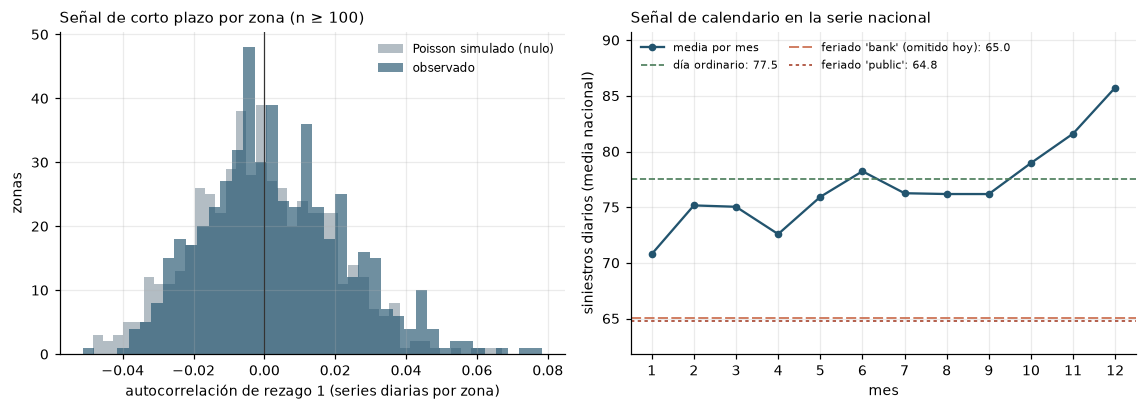

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.8))

obs_completo = obs_acf["período completo"][1]
ax1.hist(nulo_acf["período completo"][1], bins=40, color="#9aa7b1", alpha=0.75,
         label="Poisson simulado (nulo)")
ax1.hist(obs_completo[~np.isnan(obs_completo)], bins=40, color="#22546e", alpha=0.65,
         label="observado")
ax1.axvline(0, color="#333", lw=0.8)
ax1.set_xlabel("autocorrelación de rezago 1 (series diarias por zona)")
ax1.set_ylabel("zonas")
ax1.set_title(f"Señal de corto plazo por zona (n ≥ {UMBRAL_SOPORTE})", loc="left", fontsize=10)
ax1.legend(frameon=False, fontsize=8)

perfil_mes = serie_nac.groupby(serie_nac.index.month).mean()
grupos = pd.Series({"día ordinario": serie_nac[~es_public & ~es_bank].mean(),
                    "feriado 'bank' (omitido hoy)": serie_nac[es_bank].mean(),
                    "feriado 'public'": serie_nac[es_public].mean()})
ax2.plot(perfil_mes.index, perfil_mes.to_numpy(), marker="o", ms=4, color="#22546e",
         label="media por mes")
for (nombre, valor), color, guion in zip(grupos.items(), ("#4a7c59", "#c96a4a", "#a8452f"),
                                         ("--", (0, (6, 2)), (0, (2, 2)))):
    ax2.axhline(valor, ls=guion, lw=1.1, color=color, label=f"{nombre}: {valor:.1f}")
ax2.set_xticks(range(1, 13))
ax2.set_xlim(0.5, 12.5)
ax2.legend(frameon=False, fontsize=7.5, loc="upper left", ncols=2, columnspacing=1.0)
ax2.set_ylim(bottom=grupos.min() - 3, top=perfil_mes.max() + 5)
ax2.set_xlabel("mes")
ax2.set_ylabel("siniestros diarios (media nacional)")
ax2.set_title("Señal de calendario en la serie nacional", loc="left", fontsize=10)
fig.tight_layout()
guardar_figura(fig, "fig5_senal_temporal")
plt.show()

Este es el hallazgo de mayor consecuencia del diagnóstico, y conviene enunciarlo sin adornos.

**A nivel de zona no hay señal temporal de corto plazo.** En las 520 zonas con soporte suficiente
(≥ 100 siniestros en ocho años), la autocorrelación diaria mediana es **0,0015 a rezago 1 y
0,0057 a rezago 7**, frente a bandas nulas de Poisson de **[−0,032, +0,032]** y
**[−0,027, +0,030]** respectivamente: lo observado cae de lleno dentro de lo que produciría el
puro azar. El índice de dispersión por zona
—mediana **1,015**, entre 0,98 y 1,06— apunta a lo mismo: la serie diaria de una zona es
estadísticamente indistinguible de un Poisson de tasa casi constante.

Como esta conclusión orienta decisiones de modelado, se repitió el cálculo **restringido al
tramo de entrenamiento**, para no apoyar la decisión en datos reservados: la mediana es
**−0,0005 a rezago 1 y 0,0035 a rezago 7**, dentro de bandas nulas de [−0,038, +0,039] y
[−0,036, +0,037], con dispersión mediana de 1,009. La lectura no cambia; las bandas nulas se
ensanchan sólo porque hay menos días.

**A nivel nacional sí hay señal, y es de dos tipos.** El calendario (día de la semana, mes, año,
feriado) explica el **35,3 %** de la varianza del logaritmo de la serie diaria, con un patrón
nítido: viernes 85,0 frente a domingo 68,9; diciembre 85,7 frente a enero 70,8; feriados en
torno a 65 frente a 77,5 en días ordinarios. Y **queda persistencia después de descontarlo**:
la autocorrelación del residuo es 0,301 a rezago 1 y 0,180 a rezago 7 (la serie cruda daba
0,392 y 0,384). Hay días buenos y días malos que el calendario no explica —el clima es el
candidato inmediato, y es exactamente lo que la integración pendiente de Open-Meteo debería
capturar—.

**Consecuencias directas sobre el modelado**, que el informe debería declarar antes de mostrar
resultados:

1. Las features `lag_1`, `lag_7`, `lag_28` **por zona** casi no aportan información. No es un
   error incluirlas —el modelo puede descartarlas—, pero no se debe esperar de ellas el
   desempeño, y su importancia final servirá como comprobación de este diagnóstico.
2. Lo que sí informa es la **tasa histórica de la zona** (`media_365` y equivalentes) como
   estimación de intensidad espacial, combinada con **factores temporales comunes a todo el
   país** (calendario y, en el futuro, clima).
3. Esto define la **línea base correcta**: tasa de largo plazo de la zona × factor de calendario
   nacional. Una línea base más ingenua (por ejemplo, «lo mismo que ayer en esta zona») sería
   engañosamente fácil de superar y haría parecer valioso cualquier modelo.
4. El techo de desempeño alcanzable es bajo por naturaleza: si el proceso es Poisson con tasa
   λ ≈ 0,004, **ningún modelo puede predecir en qué celda concreta ocurrirá el siniestro**. Lo
   que sí puede hacerse —y es lo que el producto necesita— es **ordenar zonas y períodos por
   riesgo esperado** con calibración correcta.

### 4.4 Adecuación al objetivo del producto

Cerrando los tres ejes anteriores contra lo que el proyecto prometió entregar.

In [30]:
adecuacion = pd.DataFrame(
    [
        ("Predecir el conteo exacto de una celda-día", "No alcanzable",
         "97,4 % de las celdas positivas valen 1 y el proceso es Poisson con λ ≈ 0,004"),
        ("Estimar la intensidad esperada por zona y día", "Alcanzable",
         "hay tasa espacial estable y efecto de calendario medible"),
        ("Ordenar zonas por riesgo para un mapa", "Alcanzable",
         "la concentración espacial es fuerte y persistente entre años"),
        ("Anticipar variaciones día a día dentro de una zona", "No alcanzable con estos datos",
         "la ACF por zona no se distingue del ruido de Poisson"),
        ("Explicar días atípicos a nivel nacional", "Parcial",
         "queda ACF 0,30 en el residuo del calendario; requiere clima, aún no integrado"),
        ("Distinguir riesgo de exposición", "No alcanzable",
         "no hay volumen de tránsito ni población: sólo se observa el numerador"),
    ],
    columns=["pregunta del producto", "veredicto", "evidencia"],
)
guardar_tabla(adecuacion, "23_adecuacion_objetivo")

[tabla]  experiments\diagnostico_datos\tablas\23_adecuacion_objetivo.csv


,pregunta del producto,veredicto,evidencia
0,Predecir el conteo exacto de una celda-día,No alcanzable,"97,4 % de las celdas positivas valen 1 y el pr..."
1,Estimar la intensidad esperada por zona y día,Alcanzable,hay tasa espacial estable y efecto de calendar...
2,Ordenar zonas por riesgo para un mapa,Alcanzable,la concentración espacial es fuerte y persiste...
3,Anticipar variaciones día a día dentro de una ...,No alcanzable con estos datos,la ACF por zona no se distingue del ruido de P...
4,Explicar días atípicos a nivel nacional,Parcial,"queda ACF 0,30 en el residuo del calendario; r..."
5,Distinguir riesgo de exposición,No alcanzable,no hay volumen de tránsito ni población: sólo ...


La última fila merece énfasis porque afecta a la interpretación del mapa: los datos registran
**siniestros, no exposición**. Una zona con muchos siniestros puede ser peligrosa o simplemente
muy transitada, y sin volumen de tránsito ni población esas dos explicaciones son
indistinguibles. El producto, por tanto, no señala «zonas peligrosas» sino **zonas donde se
espera mayor cantidad de siniestros**, que es una afirmación más débil y más honesta. Para
fiscalización —el uso previsto— sigue siendo útil; para inferir causas o rediseñar
infraestructura, no alcanza.

## 5. Limitaciones y riesgos

Síntesis de lo que este diagnóstico obliga a declarar. Cada fila remite a la sección que la
sostiene, para que el informe pueda citarla sin repetir el análisis.

In [31]:
limitaciones = pd.DataFrame(
    [
        ("Sin medida de exposición", "4.4",
         "no hay tránsito ni población: el mapa mide siniestros esperados, no peligrosidad",
         "declararlo en el dashboard y en el informe; no atribuir causalidad"),
        ("Sin señal temporal por zona", "4.3",
         "los rezagos por zona no superan la banda nula de Poisson",
         "línea base tasa × calendario; no esperar desempeño de los lags"),
        ("Objetivo casi binario y extremadamente escaso", "3.4, 4.1",
         "99,6 % de ceros; 97,4 % de los positivos valen 1",
         "objetivo Poisson, submuestreo con pesos, métricas de calibración y ordenamiento"),
        ("Clima no incorporado", "3.6",
         "no hay caché de Open-Meteo en data/; queda sin explicar la ACF residual de 0,30",
         "integrar la caché del PID y verificar cobertura por zona y fecha antes de usarla"),
        ("Feature de feriados incompleta", "3.6",
         "marca 41 de 145 días con caída sistemática; omite Semana de Turismo y Carnaval",
         "usar categories=('bank','public') y evaluar una variable de período especial"),
        ("Anomalía estructural de 2020 dentro de entrenamiento", "3.1",
         "−13 % anual y abril con 1.331 siniestros frente a 2.298 de media",
         "declararla; considerar un indicador de período o ponderación al comparar particiones"),
        ("Particiones con distinta composición estacional", "3.2",
         "el corte 70/10/20 cae a mitad de año: validación sin setiembre ni octubre, test con dos diciembres",
         "no comparar el nivel de error entre validación y test; comparar modelos dentro de cada partición"),
        ("Zonas de test sin historial en entrenamiento", "3.5",
         "1.787 zonas (22,2 %) y 4,6 % de los siniestros del tramo de test",
         "estrato propio en el análisis de errores; cota inferior del error en test"),
        ("Catálogo de zonas definido con los ocho años", "3.5",
         "el universo de filas usa información posterior al corte de entrenamiento",
         "revisar antes de la evaluación final: definir el catálogo sólo con entrenamiento"),
        ("Geocodificación al eje de calle", "2.4",
         "68.152 puntos distintos para 224.694 siniestros; resolución de 5 m",
         "no analizar por debajo de la celda de 500 m"),
        ("Duplicados no resolubles", "2.2",
         "347 registros idénticos sin identificador de siniestro que los distinga",
         "se conservan; impacto acotado al 0,15 % del total"),
        ("Etiqueta departamental por moda en celdas limítrofes", "2.3",
         "57 celdas reciben siniestros de más de un departamento",
         "usar el departamento sólo para agrupar y describir, no como predictor fino"),
        ("Subregistro no cuantificable", "—",
         "sólo se observan los siniestros efectivamente registrados; no hay denominador",
         "declarar el sesgo; no interpretar ausencia de registro como ausencia de siniestro"),
    ],
    columns=["limitación", "sección", "evidencia", "tratamiento"],
)
guardar_tabla(limitaciones, "24_limitaciones")

[tabla]  experiments\diagnostico_datos\tablas\24_limitaciones.csv


,limitación,sección,evidencia,tratamiento
0,Sin medida de exposición,4.4,no hay tránsito ni población: el mapa mide sin...,declararlo en el dashboard y en el informe; no...
1,Sin señal temporal por zona,4.3,los rezagos por zona no superan la banda nula ...,línea base tasa × calendario; no esperar desem...
2,Objetivo casi binario y extremadamente escaso,"3.4, 4.1","99,6 % de ceros; 97,4 % de los positivos valen 1","objetivo Poisson, submuestreo con pesos, métri..."
3,Clima no incorporado,3.6,no hay caché de Open-Meteo en data/; queda sin...,integrar la caché del PID y verificar cobertur...
4,Feature de feriados incompleta,3.6,marca 41 de 145 días con caída sistemática; om...,"usar categories=('bank','public') y evaluar un..."
5,Anomalía estructural de 2020 dentro de entrena...,3.1,−13 % anual y abril con 1.331 siniestros frent...,declararla; considerar un indicador de período...
6,Particiones con distinta composición estacional,3.2,el corte 70/10/20 cae a mitad de año: validaci...,no comparar el nivel de error entre validación...
7,Zonas de test sin historial en entrenamiento,3.5,"1.787 zonas (22,2 %) y 4,6 % de los siniestros...",estrato propio en el análisis de errores; cota...
8,Catálogo de zonas definido con los ocho años,3.5,el universo de filas usa información posterior...,revisar antes de la evaluación final: definir ...
9,Geocodificación al eje de calle,2.4,68.152 puntos distintos para 224.694 siniestro...,no analizar por debajo de la celda de 500 m


La última fila no surge de ningún cálculo de este notebook y por eso no lleva sección: **el
subregistro no es medible con los propios datos**. El archivo contiene los siniestros que fueron
registrados; la fracción no registrada —típicamente los siniestros leves o sin lesionados que no
generan intervención— es desconocida y probablemente distinta entre Montevideo y el interior.
Que el 28 % de los registros sean «SIN LESIONADOS» sugiere una cobertura amplia, pero no
constituye una prueba. Declararlo es parte del diagnóstico; cuantificarlo exigiría una fuente
externa de contraste que el proyecto no tiene.

## 6. Artefactos generados

In [32]:
artefactos = pd.DataFrame(
    [(p.relative_to(RAIZ).as_posix(), f"{p.stat().st_size / 1024:.1f} kB")
     for p in sorted(DIR_SALIDA.rglob("*")) if p.is_file()],
    columns=["archivo", "tamaño"],
)
print(f"{len(artefactos)} archivos en {DIR_SALIDA.relative_to(RAIZ)}\n")
print(artefactos.to_string(index=False))

31 archivos en experiments\diagnostico_datos

                                                             archivo   tamaño
   experiments/diagnostico_datos/figuras/fig1_cobertura_temporal.png  89.8 kB
          experiments/diagnostico_datos/figuras/fig2_particiones.png 104.1 kB
experiments/diagnostico_datos/figuras/fig3_cobertura_territorial.png 200.3 kB
         experiments/diagnostico_datos/figuras/fig4_granularidad.png  42.7 kB
       experiments/diagnostico_datos/figuras/fig5_senal_temporal.png  67.4 kB
             experiments/diagnostico_datos/tablas/00_procedencia.csv   0.3 kB
           experiments/diagnostico_datos/tablas/01_esquema_crudo.csv   0.4 kB
experiments/diagnostico_datos/tablas/01b_composicion_descriptiva.csv   0.6 kB
experiments/diagnostico_datos/tablas/02_disponibilidad_variables.csv   0.7 kB
             experiments/diagnostico_datos/tablas/03_completitud.csv   0.3 kB
              experiments/diagnostico_datos/tablas/04_duplicados.csv   0.2 kB
            experi

Cada cifra citada en la sección *Metodología — datos* del informe debe remitir a uno de estos
archivos o a una celda de este notebook. El notebook es determinista: la única fuente de azar es
la simulación nula de la sección 4.3, fijada con `SEMILLA = 42`.

**Pendientes que este diagnóstico deja abiertos**, en orden de prioridad:

1. Resolver la discrepancia de granularidad entre `analisis_inicial.ipynb` (500 m) y los
   artefactos de `data/processed/` (1 km), y regenerar los derivados (2.6).
2. Alinear el corte de particiones de `analisis_inicial.ipynb` —hoy por años completos— con la
   división 70/10/20 de la sección 3.2, lo que implica filtrar por fecha y no por directorio de
   año al leer las *features*.
3. Integrar la caché climática de Open-Meteo y repetir el análisis de señal residual (3.6, 4.3).
4. Corregir la construcción de `es_feriado` en `analisis_inicial.ipynb` (3.6).
5. Decidir si el catálogo de zonas se redefine usando sólo entrenamiento (3.5).
6. Fijar las métricas del Entregable 2 en coherencia con un objetivo Poisson casi binario:
   desvianza de Poisson, calibración por estrato de soporte y métricas de ordenamiento (4.1, 4.3).
7. Definir la línea base como tasa histórica de la zona × factor de calendario, y no como una
   regla de persistencia (4.3).